# Import datasets

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Data

## Data Record Screening

In [3]:
def final_filtering_pipeline(df):
    """
    Final Filtering Pipeline
    Steps:
    1. Patient deduplication (keep first visit for each patient)
    2. Exclude death/hospice records
    """
    print("Starting final screening...")
    
    # 1. Patient deduplication
    print("1. Patient deduplication...")
    df_sorted = df.sort_values(['patient_nbr', 'encounter_id'])
    df_deduped = df_sorted.drop_duplicates(subset=['patient_nbr'], keep='first')
    print(f"   Original: {len(df):,} → After deduplication: {len(df_deduped):,}")
    
    # 2. Exclude death/hospice records
    print("2. Excluding death/hospice records...")
    exclude_codes = [11, 13, 14, 19, 20, 21]
    df_final = df_deduped[~df_deduped['discharge_disposition_id'].isin(exclude_codes)].copy()
    
    # Statistics
    original_count = len(df)
    deduped_count = len(df_deduped)
    final_count = len(df_final)
    
    print(f"\nScreening Results:")
    print(f"Original record count: {original_count:,}")
    print(f"Record count after deduplication: {deduped_count:,} (Duplicates excluded: {original_count - deduped_count:,})")
    print(f"Death/hospice records excluded: {deduped_count - final_count:,}")
    print(f"Final record count: {final_count:,}")
    
    return df_final

# Execute final screening
df = final_filtering_pipeline(df)

Starting final screening...
1. Patient deduplication...
   Original: 101,766 → After deduplication: 71,518
2. Excluding death/hospice records...

Screening Results:
Original record count: 101,766
Record count after deduplication: 71,518 (Duplicates excluded: 30,248)
Death/hospice records excluded: 1,545
Final record count: 69,973


## Feature Construction

### Extraction of Original Features

In [4]:
df2 = df[['encounter_id','patient_nbr','race','gender','age','diag_1','diag_2','diag_3', 'glipizide', 'glyburide', 'metformin']].copy()
df2.head()

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin
4267,24437208,135,Caucasian,Female,[50-60),401,997,560,No,Down,Steady
5827,29758806,378,Caucasian,Female,[50-60),722,305,250,No,No,No
67608,189899286,729,Caucasian,Female,[80-90),820,493,E880,No,No,Steady
17494,64331490,774,Caucasian,Female,[80-90),274,427,416,No,Steady,Steady
2270,14824206,927,AfricanAmerican,Female,[30-40),590,220,250,No,No,No


In [5]:
gender_map = {'Female': 0, 'Male': 1,'Unknown/Invalid':2}
df2['gender'] = df2['gender'].map(gender_map)

# Verification
print("Gender column conversion completed!")
print(f"0 (Female) count: {(df2['gender'] == 0).sum()}")
print(f"1 (Male) count: {(df2['gender'] == 1).sum()}")
print(f"2 (Unknown/Invalid) count: {(df2['gender'] == 2).sum()}")  
print(f"Gender column data type: {df2['gender'].dtype}")

Gender column conversion completed!
0 (Female) count: 37229
1 (Male) count: 32741
2 (Unknown/Invalid) count: 3
Gender column data type: int64


In [6]:
# Define a dictionary
age_order = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9,
    '[100-110)': 10
}

# Apply the dictionary
df2['age'] = df2['age'].map(age_order)

In [7]:
df2

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin
4267,24437208,135,Caucasian,0,5,401,997,560,No,Down,Steady
5827,29758806,378,Caucasian,0,5,722,305,250,No,No,No
67608,189899286,729,Caucasian,0,8,820,493,E880,No,No,Steady
17494,64331490,774,Caucasian,0,8,274,427,416,No,Steady,Steady
2270,14824206,927,AfricanAmerican,0,3,590,220,250,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
99863,418513058,189351095,Caucasian,0,8,285,401,496,No,No,No
95282,359719064,189365864,Other,1,6,584,250.02,403,No,No,No
93651,338462954,189445127,Caucasian,0,8,486,414,733,Up,No,Steady
101748,443811536,189481478,Caucasian,0,4,295,305,250,No,Steady,Up


### Construction of Clinical Features

In [8]:
df2['blood_pressure'] = 0  
df2['alcohol'] = 0        
df2['cholesterol'] = 0    
df2['heart_disease'] = 0   
df2['obesity'] = 0        
df2['pregnancy'] = 0       
df2['uric_acid'] = 0       
df2['blurred_vision'] = 0  
df2.head()

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision
4267,24437208,135,Caucasian,0,5,401,997,560,No,Down,Steady,0,0,0,0,0,0,0,0
5827,29758806,378,Caucasian,0,5,722,305,250,No,No,No,0,0,0,0,0,0,0,0
67608,189899286,729,Caucasian,0,8,820,493,E880,No,No,Steady,0,0,0,0,0,0,0,0
17494,64331490,774,Caucasian,0,8,274,427,416,No,Steady,Steady,0,0,0,0,0,0,0,0
2270,14824206,927,AfricanAmerican,0,3,590,220,250,No,No,No,0,0,0,0,0,0,0,0


In [9]:
# Define hypertension-related ICD-9 codes
bloodpressure_codes = ['401', '402', '403', '404', '405', '642']

def check_bloodpressure(row):
    """
    Check if a row of data has hypertension
    """
    # Check if there are hypertension codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in bloodpressure_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['blood_pressure'] = df2.apply(check_bloodpressure, axis=1)

In [10]:
# Define alcohol-related ICD-9 codes
alcohol_codes = ['303', '305.0', '571.0', '571.1', '571.2', '571.3']

def check_alcohol(row):
    """
    Check if a row of data has alcohol-related issues
    """
    # Check if there are alcohol codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in alcohol_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['alcohol'] = df2.apply(check_alcohol, axis=1)

In [11]:
# Define cholesterol-related ICD-9 codes
cholesterol_codes = ['272']

def check_cholesterol(row):
    """
    Check if a row of data has cholesterol-related issues
    """
    # Check if there are cholesterol codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in cholesterol_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['cholesterol'] = df2.apply(check_cholesterol, axis=1)

In [12]:
# Define heart disease-related ICD-9 codes
heartdisease_codes = ['401', '402', '403', '404', '405', '642']

def check_heartdisease(row):
    """
    Check if a row of data has heart disease-related issues
    """
    # Check if there are heart disease codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in heartdisease_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['heart_disease'] = df2.apply(check_heartdisease, axis=1)

In [13]:
# Define obesity-related ICD-9 codes
obesity_codes = ['278']

def check_obesity(row):
    """
    Check if a row of data has obesity-related issues
    """
    # Check if there are obesity codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in obesity_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['obesity'] = df2.apply(check_obesity, axis=1)

In [14]:
# Define pregnancy-related ICD-9 codes
pregnancy_codes = ['630', '631', '632', '633', '634', '635', '636', '637', '638', '639', '640', '641', '642', '643', '644', '645', '646', '647', '648','649']

def check_pregnancy(row):
    """
    Check if a row of data has pregnancy-related issues
    """
    # Check if there are pregnancy codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in pregnancy_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['pregnancy'] = df2.apply(check_pregnancy, axis=1)

In [15]:
# Define uric acid-related ICD-9 codes
uricacid_codes = ['274','790.6']

def check_uricacid(row):
    """
    Check if a row of data has uric acid-related issues
    """
    # Check if there are uric acid codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in uricacid_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['uric_acid'] = df2.apply(check_uricacid, axis=1)

In [16]:
# Define blurred vision-related ICD-9 codes
blurredvision_codes = ['368']

def check_blurredvision(row):
    """
    Check if a row of data has blurred vision-related issues
    """
    # Check if there are blurred vision codes in diag_1, diag_2, diag_3
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        # Convert diagnosis code to string and check
        diag_str = str(diag)
        for code in uricacid_codes:
            if diag_str.startswith(code):
                return 1
    return 0

# Apply function
df2['blurred_vision'] = df2.apply(check_blurredvision, axis=1)

In [17]:
df2.head()

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision
4267,24437208,135,Caucasian,0,5,401,997,560,No,Down,Steady,1,0,0,1,0,0,0,0
5827,29758806,378,Caucasian,0,5,722,305,250,No,No,No,0,0,0,0,0,0,0,0
67608,189899286,729,Caucasian,0,8,820,493,E880,No,No,Steady,0,0,0,0,0,0,0,0
17494,64331490,774,Caucasian,0,8,274,427,416,No,Steady,Steady,0,0,0,0,0,0,1,1
2270,14824206,927,AfricanAmerican,0,3,590,220,250,No,No,No,0,0,0,0,0,0,0,0


### Construction of the Target Variable

In [18]:
df2['diabetes2'] = 0 
df2.head()

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision,diabetes2
4267,24437208,135,Caucasian,0,5,401,997,560,No,Down,Steady,1,0,0,1,0,0,0,0,0
5827,29758806,378,Caucasian,0,5,722,305,250,No,No,No,0,0,0,0,0,0,0,0,0
67608,189899286,729,Caucasian,0,8,820,493,E880,No,No,Steady,0,0,0,0,0,0,0,0,0
17494,64331490,774,Caucasian,0,8,274,427,416,No,Steady,Steady,0,0,0,0,0,0,1,1,0
2270,14824206,927,AfricanAmerican,0,3,590,220,250,No,No,No,0,0,0,0,0,0,0,0,0


In [19]:
import re

def check_diabetes2(row):
    """
    Check if a row of data has type 2 diabetes-related issues
    """
    # Check condition 1: ICD9 code = 250.x0 or 250.x2
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        
        diag_str = str(diag)
        # Use regex to match 250.x0 or 250.x2 pattern
        if re.match(r'^250\.[0-9][02]$', diag_str):
            return 1
    
    # Check condition 2: ICD9 code = 250 or 250.x AND one of the medicines prescribed
    for diag in [row['diag_1'], row['diag_2'], row['diag_3']]:
        if pd.isna(diag) or diag == '?':
            continue
        
        diag_str = str(diag)
        
        # Check if diagnosis code matches 250 or 250.x (x = 0-9)
        if diag_str == '250' or re.match(r'^250\.[0-9]$', diag_str):
            # Check if any of the three medicines was prescribed (not "no")
            if (row.get('metformin', 'No') != 'No' or 
                row.get('glimepiride', 'No') != 'No' or 
                row.get('glipizide', 'No') != 'No'):
                return 1
    
    return 0

# Apply function
df2['diabetes2'] = df2.apply(check_diabetes2, axis=1)

In [20]:
df2

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision,diabetes2
4267,24437208,135,Caucasian,0,5,401,997,560,No,Down,Steady,1,0,0,1,0,0,0,0,0
5827,29758806,378,Caucasian,0,5,722,305,250,No,No,No,0,0,0,0,0,0,0,0,0
67608,189899286,729,Caucasian,0,8,820,493,E880,No,No,Steady,0,0,0,0,0,0,0,0,0
17494,64331490,774,Caucasian,0,8,274,427,416,No,Steady,Steady,0,0,0,0,0,0,1,1,0
2270,14824206,927,AfricanAmerican,0,3,590,220,250,No,No,No,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99863,418513058,189351095,Caucasian,0,8,285,401,496,No,No,No,1,0,0,1,0,0,0,0,0
95282,359719064,189365864,Other,1,6,584,250.02,403,No,No,No,1,0,0,1,0,0,0,0,1
93651,338462954,189445127,Caucasian,0,8,486,414,733,Up,No,Steady,0,0,0,0,0,0,0,0,0
101748,443811536,189481478,Caucasian,0,4,295,305,250,No,Steady,Up,0,0,0,0,0,0,0,0,1


## Missing Value Handling and Feature Selection

### Gender

In [21]:
# Check number of unique values
print(f"Number of unique values: {df2['gender'].nunique()}")
# Check what unique values exist
print(f"Unique values: {df2['gender'].unique()}")
# Check frequency of each category (sorted from high to low)
value_counts = df2['gender'].value_counts()
print(value_counts)
# Check frequency with percentages
value_counts_percent = df2['gender'].value_counts(normalize=True)
print(value_counts_percent)

Number of unique values: 3
Unique values: [0 1 2]
gender
0    37229
1    32741
2        3
Name: count, dtype: int64
gender
0    0.532048
1    0.467909
2    0.000043
Name: proportion, dtype: float64


In [22]:
df2= df2[df2['gender'] != 2].copy()

In [23]:
df2

,encounter_id,patient_nbr,race,gender,age,diag_1,diag_2,diag_3,glipizide,glyburide,metformin,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision,diabetes2
4267,24437208,135,Caucasian,0,5,401,997,560,No,Down,Steady,1,0,0,1,0,0,0,0,0
5827,29758806,378,Caucasian,0,5,722,305,250,No,No,No,0,0,0,0,0,0,0,0,0
67608,189899286,729,Caucasian,0,8,820,493,E880,No,No,Steady,0,0,0,0,0,0,0,0,0
17494,64331490,774,Caucasian,0,8,274,427,416,No,Steady,Steady,0,0,0,0,0,0,1,1,0
2270,14824206,927,AfricanAmerican,0,3,590,220,250,No,No,No,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99863,418513058,189351095,Caucasian,0,8,285,401,496,No,No,No,1,0,0,1,0,0,0,0,0
95282,359719064,189365864,Other,1,6,584,250.02,403,No,No,No,1,0,0,1,0,0,0,0,1
93651,338462954,189445127,Caucasian,0,8,486,414,733,Up,No,Steady,0,0,0,0,0,0,0,0,0
101748,443811536,189481478,Caucasian,0,4,295,305,250,No,Steady,Up,0,0,0,0,0,0,0,0,1


### Delete irrelevant columns

In [24]:
df2.drop(['diag_1', 'diag_2', 'diag_3','encounter_id','patient_nbr', 'glipizide', 'glyburide', 'metformin'], axis=1, inplace=True)
df2

,race,gender,age,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision,diabetes2
4267,Caucasian,0,5,1,0,0,1,0,0,0,0,0
5827,Caucasian,0,5,0,0,0,0,0,0,0,0,0
67608,Caucasian,0,8,0,0,0,0,0,0,0,0,0
17494,Caucasian,0,8,0,0,0,0,0,0,1,1,0
2270,AfricanAmerican,0,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99863,Caucasian,0,8,1,0,0,1,0,0,0,0,0
95282,Other,1,6,1,0,0,1,0,0,0,0,1
93651,Caucasian,0,8,0,0,0,0,0,0,0,0,0
101748,Caucasian,0,4,0,0,0,0,0,0,0,0,1


# Discreption statistics

🎯 Target Variable Distribution:
                 Number of Cases  Percentage
Non-Diabetic(0)            58658       83.83
Diabetic(1)                11312       16.17

⚠️ Class Imbalance Ratio (Non-Diabetic:Diabetic): 5.19:1


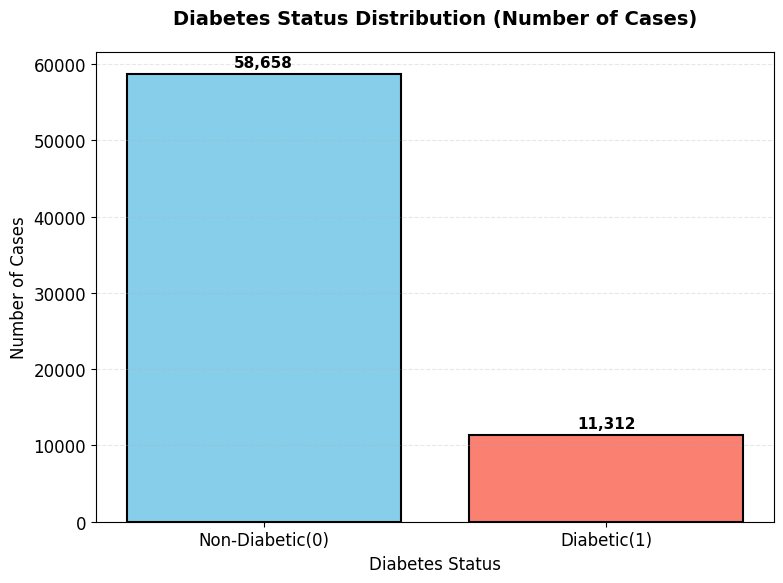

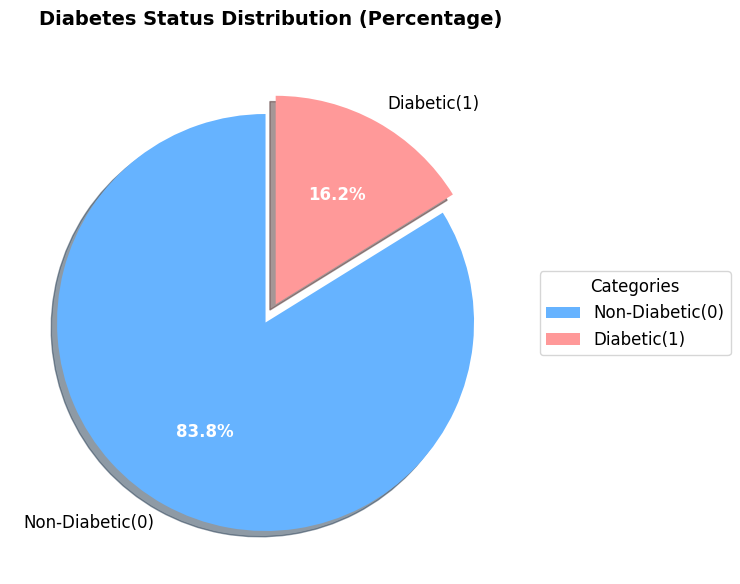


📊 Summary Statistics:
Total cases: 69,970
Non-diabetic cases: 58,658 (83.83%)
Diabetic cases: 11,312 (16.17%)


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Diabetes Status Distribution
diabetes_dist = df2['diabetes2'].value_counts().sort_index()
diabetes_percent = df2['diabetes2'].value_counts(normalize=True).sort_index() * 100

# Create distribution table
diabetes_summary = pd.DataFrame({
    'Number of Cases': diabetes_dist,
    'Percentage': diabetes_percent.round(2)
})
diabetes_summary.index = ['Non-Diabetic(0)', 'Diabetic(1)']

print("🎯 Target Variable Distribution:")
print(diabetes_summary)

# Calculate class imbalance ratio
n_non_diabetic = diabetes_dist[0]
n_diabetic = diabetes_dist[1]
imbalance_ratio = n_non_diabetic / n_diabetic
print(f"\n⚠️ Class Imbalance Ratio (Non-Diabetic:Diabetic): {imbalance_ratio:.2f}:1")

# Set global font size for better readability
plt.rcParams.update({'font.size': 12})

# 1. Bar chart - Separate figure
plt.figure(figsize=(8, 6))
bars = plt.bar(diabetes_summary.index, diabetes_summary['Number of Cases'], 
               color=['skyblue', 'salmon'], edgecolor='black', linewidth=1.5)
plt.title('Diabetes Status Distribution (Number of Cases)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of Cases', fontsize=12)
plt.xlabel('Diabetes Status', fontsize=12)

# Add values on top of bars
for i, v in enumerate(diabetes_summary['Number of Cases']):
    plt.text(i, v + max(diabetes_summary['Number of Cases']) * 0.01, 
             f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Customize grid
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 2. Pie chart - Separate figure
plt.figure(figsize=(8, 6))
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)  # Slight separation between slices

wedges, texts, autotexts = plt.pie(
    diabetes_summary['Percentage'], 
    labels=diabetes_summary.index, 
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True
)

plt.title('Diabetes Status Distribution (Percentage)', fontsize=14, fontweight='bold', pad=20)

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# Add a legend
plt.legend(wedges, diabetes_summary.index,
           title="Categories",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Summary Statistics:")
print(f"Total cases: {n_non_diabetic + n_diabetic:,}")
print(f"Non-diabetic cases: {n_non_diabetic:,} ({diabetes_summary.loc['Non-Diabetic(0)', 'Percentage']}%)")
print(f"Diabetic cases: {n_diabetic:,} ({diabetes_summary.loc['Diabetic(1)', 'Percentage']}%)")

In [26]:
df2

,race,gender,age,blood_pressure,alcohol,cholesterol,heart_disease,obesity,pregnancy,uric_acid,blurred_vision,diabetes2
4267,Caucasian,0,5,1,0,0,1,0,0,0,0,0
5827,Caucasian,0,5,0,0,0,0,0,0,0,0,0
67608,Caucasian,0,8,0,0,0,0,0,0,0,0,0
17494,Caucasian,0,8,0,0,0,0,0,0,1,1,0
2270,AfricanAmerican,0,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99863,Caucasian,0,8,1,0,0,1,0,0,0,0,0
95282,Other,1,6,1,0,0,1,0,0,0,0,1
93651,Caucasian,0,8,0,0,0,0,0,0,0,0,0
101748,Caucasian,0,4,0,0,0,0,0,0,0,0,1


# Method

In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.metrics import average_precision_score
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
rcParams['figure.figsize'] = 10, 6

## Feature Engineering and Dataset Partitioning

In [28]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def create_multimodel_feature_engineering(df):
    """
    Create feature engineering for multiple models.
    Returns: Three versions of feature datasets.
    1. df_for_lr: For Logistic Regression (one-hot encoding + interactions + polynomials).
    2. df_for_trees: For Tree Models (label encoding + risk scores).
    3. df_for_nn: For Neural Networks (one-hot encoding + rich features).
    """
    
    print("=" * 60)
    print("Processing Feature Engineering for Multiple Models...")
    print(f"Original data shape: {df.shape}")
    print("=" * 60)
    
    # Validate feature presence
    expected_features = ['race', 'gender', 'age', 'alcohol', 'blood_pressure',
                         'cholesterol', 'heart_disease', 'obesity', 'pregnancy',
                         'uric_acid', 'blurred_vision', 'diabetes2']
    
    missing_features = [f for f in expected_features if f not in df.columns]
    if missing_features:
        print(f"⚠️ Warning: Missing features: {missing_features}")
    else:
        print("✅ All required features are present")
    
    # Check class imbalance
    print(f"\nClass Distribution in Original Data:")
    class_counts = df['diabetes2'].value_counts()
    class_ratio = class_counts[0] / class_counts[1] if class_counts[1] > 0 else 0
    print(f"  Class 0 (No Diabetes): {class_counts[0]} samples ({class_counts[0]/len(df)*100:.1f}%)")
    print(f"  Class 1 (Diabetes): {class_counts[1]} samples ({class_counts[1]/len(df)*100:.1f}%)")
    print(f"  Imbalance Ratio: {class_ratio:.2f}:1")
    
    # Create base data copy
    df_base = df.copy()
    
    # ============== Version 1: Logistic Regression Feature Engineering ==============
    print("\n" + "-" * 40)
    print("Creating Logistic Regression Feature Engineering...")
    df_lr = df_base.copy()
    
    # 1. Race Feature: One-hot encoding (drop_first to avoid multicollinearity)
    if 'race' in df_lr.columns:
        race_dummies = pd.get_dummies(df_lr['race'], prefix='race', drop_first=True)
        df_lr = pd.concat([df_lr.drop('race', axis=1), race_dummies], axis=1)
        print(f"  Race Feature: One-hot encoding → {race_dummies.shape[1]} dummy variables")
    
    # 2. Create interaction and polynomial features
    if 'age' in df_lr.columns and 'obesity' in df_lr.columns:
        df_lr['age_obesity'] = df_lr['age'] * df_lr['obesity']
    
    if 'age' in df_lr.columns and 'blood_pressure' in df_lr.columns:
        df_lr['age_bp'] = df_lr['age'] * df_lr['blood_pressure']
    
    if 'age' in df_lr.columns:
        df_lr['age_squared'] = df_lr['age'] ** 2
    
    print(f"  Logistic Regression Feature Count: {df_lr.shape[1]}")
    
    # ============== Version 2: Tree Model Feature Engineering ==============
    print("\n" + "-" * 40)
    print("Creating Tree Model Feature Engineering...")
    df_trees = df_base.copy()
    
    # 1. Race Feature: Label encoding (preferred by tree models)
    if 'race' in df_trees.columns:
        le = LabelEncoder()
        df_trees['race_encoded'] = le.fit_transform(df_trees['race'])
        df_trees = df_trees.drop('race', axis=1)
        print(f"  Race Feature: Label encoding")
    
    # 2. Create risk score feature (beneficial for tree models)
    risk_factors = ['obesity', 'blood_pressure', 'cholesterol', 'heart_disease']
    existing_risk = [f for f in risk_factors if f in df_trees.columns]
    
    if existing_risk:
        df_trees['risk_score'] = df_trees[existing_risk].sum(axis=1)
        print(f"  Risk Score: Based on {len(existing_risk)} risk factors")
    
    # 3. Create age group feature
    if 'age' in df_trees.columns:
        # Create age groups: young(0-3), middle(4-6), old(7-9)
        df_trees['age_group'] = pd.cut(
            df_trees['age'],
            bins=[-1, 3, 6, 10],
            labels=['young', 'middle', 'old']
        )
        
        # Label encode age group
        age_le = LabelEncoder()
        df_trees['age_group_encoded'] = age_le.fit_transform(df_trees['age_group'])
        df_trees = df_trees.drop('age_group', axis=1)
        print(f"  Age Group: Categorical encoding")
    
    print(f"  Tree Model Feature Count: {df_trees.shape[1]}")
    
    # ============== Version 3: Neural Network Feature Engineering ==============
    print("\n" + "-" * 40)
    print("Creating Neural Network Feature Engineering...")
    df_nn = df_base.copy()
    
    # 1. Race Feature: Full one-hot encoding (neural networks can handle it)
    if 'race' in df_nn.columns:
        race_dummies_nn = pd.get_dummies(df_nn['race'], prefix='race', drop_first=False)
        df_nn = pd.concat([df_nn.drop('race', axis=1), race_dummies_nn], axis=1)
        print(f"  Race Feature: Full one-hot encoding → {race_dummies_nn.shape[1]} dummy variables")
    
    # 2. Create rich feature transformations
    if 'age' in df_nn.columns:
        # Multiple age transformations
        df_nn['age_squared'] = df_nn['age'] ** 2
        df_nn['age_log'] = np.log1p(df_nn['age'])
        df_nn['age_normalized'] = (df_nn['age'] - df_nn['age'].mean()) / df_nn['age'].std()
        print(f"  Age Feature: 3 transformations")
    
    # 3. Create more interaction features
    interactions = [
        ('age', 'obesity'),
        ('age', 'blood_pressure'),
        ('age', 'cholesterol'),
        ('blood_pressure', 'cholesterol')
    ]
    
    created_interactions = 0
    for feat1, feat2 in interactions:
        if feat1 in df_nn.columns and feat2 in df_nn.columns:
            df_nn[f'{feat1}_{feat2}'] = df_nn[feat1] * df_nn[feat2]
            created_interactions += 1
    
    print(f"  Interaction Features: {created_interactions}")
    
    print(f"  Neural Network Feature Count: {df_nn.shape[1]}")
    
    # ============== Final Statistics ==============
    print("\n" + "=" * 60)
    print("Multi-model Feature Engineering Complete!")
    print(f"Original Feature Count: {df_base.shape[1] - 1}")  # Subtract target variable
    print(f"Logistic Regression Feature Count: {df_lr.shape[1] - 1}")
    print(f"Tree Model Feature Count: {df_trees.shape[1] - 1}")
    print(f"Neural Network Feature Count: {df_nn.shape[1] - 1}")
    print("=" * 60)
    
    # Verify target variable is consistent across all versions
    assert all(df_lr['diabetes2'] == df_base['diabetes2']), "Target variable mismatch"
    assert all(df_trees['diabetes2'] == df_base['diabetes2']), "Target variable mismatch"
    assert all(df_nn['diabetes2'] == df_base['diabetes2']), "Target variable mismatch"
    
    return df_lr, df_trees, df_nn


def create_multimodel_datasets(df_lr, df_trees, df_nn, test_size=0.15, val_size=0.15, random_state=42):
    """
    Create datasets for multiple models.
    Returns training, validation, and test sets for each model.
    """
    
    print("=" * 60)
    print("Creating Multi-model Dataset Splits...")
    print("=" * 60)
    
    # Store all datasets
    datasets = {}
    
    # Create datasets for each feature version
    for model_type, df in [('lr', df_lr), ('trees', df_trees), ('nn', df_nn)]:
        print(f"\nProcessing {model_type.upper()} feature version...")
        
        # Separate features and target variable
        X = df.drop('diabetes2', axis=1)
        y = df['diabetes2']
        
        # First split: train+validation set and test set
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=random_state,
            stratify=y  
        )
        
        # Then split validation set from train+validation set
        val_size_adjusted = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp,
            test_size=val_size_adjusted,
            random_state=random_state,
            stratify=y_temp  
        )
        
        # Store datasets
        datasets[model_type] = {
            'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test
        }
        
        print(f"  Training Set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
        print(f"  Validation Set: {X_val.shape[0]} samples")
        print(f"  Test Set: {X_test.shape[0]} samples")
        print(f"  Class Distribution - Train: {np.bincount(y_train)}, Val: {np.bincount(y_val)}, Test: {np.bincount(y_test)}")
    
    return datasets


def create_scaled_datasets_for_lr_nn(datasets):
    """
    Create standardized versions of datasets for Logistic Regression and Neural Networks.
    """
    print("\n" + "=" * 60)
    print("Creating Standardized Datasets for Logistic Regression and Neural Networks...")
    print("=" * 60)
    
    scaled_datasets = datasets.copy()
    
    # Models requiring standardization
    models_needing_scaling = ['lr', 'nn']
    
    for model_type in models_needing_scaling:
        print(f"\nStandardizing {model_type.upper()} features...")
        
        # Get original datasets
        X_train = datasets[model_type]['X_train']
        X_val = datasets[model_type]['X_val']
        X_test = datasets[model_type]['X_test']
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)
        
        # Convert to DataFrame (preserving column names)
        X_train_scaled_df = pd.DataFrame(
            X_train_scaled,
            columns=X_train.columns,
            index=X_train.index
        )
        X_val_scaled_df = pd.DataFrame(
            X_val_scaled,
            columns=X_val.columns,
            index=X_val.index
        )
        X_test_scaled_df = pd.DataFrame(
            X_test_scaled,
            columns=X_test.columns,
            index=X_test.index
        )
        
        # Update datasets
        scaled_datasets[f'{model_type}_scaled'] = {
            'X_train': X_train_scaled_df,
            'X_val': X_val_scaled_df,
            'X_test': X_test_scaled_df,
            'y_train': datasets[model_type]['y_train'],
            'y_val': datasets[model_type]['y_val'],
            'y_test': datasets[model_type]['y_test'],
            'scaler': scaler  # Save the scaler
        }
        
        print(f"  Standardization complete (mean=0, std=1)")
    
    return scaled_datasets


def apply_smote_to_datasets(datasets, sampling_strategy='auto', random_state=42):
    """
    Apply SMOTE oversampling to handle class imbalance in training sets.
    
    Parameters:
    -----------
    datasets : dict
        Dictionary containing datasets for each model type
    sampling_strategy : float, str or dict
        Sampling strategy for SMOTE. Can be:
        - 'auto': balance classes (default)
        - float: ratio of minority to majority samples
        - dict: specify desired number of samples per class
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict: Datasets with oversampled training sets
    """
    print("\n" + "=" * 60)
    print("Applying SMOTE Oversampling to Handle Class Imbalance")
    print("=" * 60)
    
    # Create a copy to avoid modifying original datasets
    oversampled_datasets = datasets.copy()
    
    for model_type, data in datasets.items():
        print(f"\nApplying SMOTE to {model_type.upper()} training set...")
        
        # Get training data
        X_train = data['X_train']
        y_train = data['y_train']
        
        # Check current class distribution
        class_counts_before = np.bincount(y_train)
        print(f"  Before SMOTE - Class distribution: {class_counts_before}")
        print(f"    Class 0: {class_counts_before[0]} samples ({class_counts_before[0]/len(y_train)*100:.1f}%)")
        print(f"    Class 1: {class_counts_before[1]} samples ({class_counts_before[1]/len(y_train)*100:.1f}%)")
        
        # Apply SMOTE
        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            random_state=random_state,
            k_neighbors=min(5, class_counts_before[1])  # Adjust k_neighbors based on minority class size
        )
        
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        
        # Check new class distribution
        class_counts_after = np.bincount(y_train_resampled)
        print(f"  After SMOTE - Class distribution: {class_counts_after}")
        print(f"    Class 0: {class_counts_after[0]} samples ({class_counts_after[0]/len(y_train_resampled)*100:.1f}%)")
        print(f"    Class 1: {class_counts_after[1]} samples ({class_counts_after[1]/len(y_train_resampled)*100:.1f}%)")
        print(f"  Added {len(y_train_resampled) - len(y_train)} synthetic samples")
        
        # Update dataset with resampled training data
        oversampled_datasets[model_type]['X_train'] = X_train_resampled
        oversampled_datasets[model_type]['y_train'] = y_train_resampled
        
        # Store SMOTE info
        oversampled_datasets[model_type]['smote'] = smote
        oversampled_datasets[model_type]['original_train_size'] = len(y_train)
        oversampled_datasets[model_type]['resampled_train_size'] = len(y_train_resampled)
    
    return oversampled_datasets


def apply_hybrid_sampling_to_datasets(datasets, over_sampling_strategy=0.5, under_sampling_strategy=0.8, random_state=42):
    """
    Apply hybrid sampling (SMOTE + RandomUnderSampler) for more balanced approach.
    
    Parameters:
    -----------
    datasets : dict
        Dictionary containing datasets for each model type
    over_sampling_strategy : float
        SMOTE oversampling strategy (minority class ratio)
    under_sampling_strategy : float
        RandomUnderSampler strategy (majority class ratio)
    random_state : int
        Random seed for reproducibility
    """
    print("\n" + "=" * 60)
    print("Applying Hybrid Sampling (SMOTE + RandomUnderSampler)")
    print("=" * 60)
    
    # Create a copy to avoid modifying original datasets
    hybrid_datasets = datasets.copy()
    
    for model_type, data in datasets.items():
        print(f"\nApplying hybrid sampling to {model_type.upper()} training set...")
        
        # Get training data
        X_train = data['X_train']
        y_train = data['y_train']
        
        # Check current class distribution
        class_counts_before = np.bincount(y_train)
        print(f"  Before sampling - Class distribution: {class_counts_before}")
        
        # Create pipeline for hybrid sampling
        over = SMOTE(sampling_strategy=over_sampling_strategy, random_state=random_state)
        under = RandomUnderSampler(sampling_strategy=under_sampling_strategy, random_state=random_state)
        pipeline = Pipeline([('over', over), ('under', under)])
        
        X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)
        
        # Check new class distribution
        class_counts_after = np.bincount(y_train_resampled)
        print(f"  After hybrid sampling - Class distribution: {class_counts_after}")
        print(f"  Total samples: {len(y_train_resampled)} (from {len(y_train)})")
        
        # Update dataset with resampled training data
        hybrid_datasets[model_type]['X_train'] = X_train_resampled
        hybrid_datasets[model_type]['y_train'] = y_train_resampled
        
        # Store pipeline info
        hybrid_datasets[model_type]['sampling_pipeline'] = pipeline
    
    return hybrid_datasets


def prepare_all_model_datasets(df_original, apply_smote=True, sampling_method='smote', random_state=42):
    """
    Complete preparation workflow with optional oversampling.
    
    Parameters:
    -----------
    df_original : DataFrame
        Original dataset with diabetes2 target column
    apply_smote : bool
        Whether to apply SMOTE oversampling
    sampling_method : str
        'smote' or 'hybrid' sampling method
    random_state : int
        Random seed for reproducibility
    """
    print("=" * 60)
    print("Starting Dataset Preparation for All Models")
    print("=" * 60)
    
    # 1. Create multi-model feature engineering
    df_lr, df_trees, df_nn = create_multimodel_feature_engineering(df_original)
    
    # 2. Create dataset splits
    datasets = create_multimodel_datasets(df_lr, df_trees, df_nn, random_state=random_state)
    
    # 3. Create standardized versions for models requiring it
    all_datasets = create_scaled_datasets_for_lr_nn(datasets)
    
    # 4. Apply SMOTE if requested (only to training sets)
    if apply_smote:
        if sampling_method == 'smote':
            # Apply standard SMOTE
            all_datasets = apply_smote_to_datasets(all_datasets, random_state=random_state)
        elif sampling_method == 'hybrid':
            # Apply hybrid sampling
            all_datasets = apply_hybrid_sampling_to_datasets(all_datasets, random_state=random_state)
        else:
            print(f"\n⚠️ Unknown sampling method: {sampling_method}. Using SMOTE.")
            all_datasets = apply_smote_to_datasets(all_datasets, random_state=random_state)
    else:
        print("\n⚠️ SMOTE not applied. Training with original class distribution.")
    
    # 5. Organize final datasets
    final_datasets = {
        # Logistic Regression: Use standardized version
        'logistic_regression': {
            'train': (all_datasets['lr_scaled']['X_train'], all_datasets['lr_scaled']['y_train']),
            'val': (all_datasets['lr_scaled']['X_val'], all_datasets['lr_scaled']['y_val']),
            'test': (all_datasets['lr_scaled']['X_test'], all_datasets['lr_scaled']['y_test']),
            'scaler': all_datasets['lr_scaled'].get('scaler'),
            'smote': all_datasets['lr_scaled'].get('smote') if apply_smote else None
        },
        
        # Random Forest: Use original tree model version
        'random_forest': {
            'train': (all_datasets['trees']['X_train'], all_datasets['trees']['y_train']),
            'val': (all_datasets['trees']['X_val'], all_datasets['trees']['y_val']),
            'test': (all_datasets['trees']['X_test'], all_datasets['trees']['y_test']),
            'smote': all_datasets['trees'].get('smote') if apply_smote else None
        },
        
        # XGBoost: Use original tree model version
        'xgboost': {
            'train': (all_datasets['trees']['X_train'], all_datasets['trees']['y_train']),
            'val': (all_datasets['trees']['X_val'], all_datasets['trees']['y_val']),
            'test': (all_datasets['trees']['X_test'], all_datasets['trees']['y_test']),
            'smote': all_datasets['trees'].get('smote') if apply_smote else None
        },
        
        # Neural Network: Use standardized version
        'neural_network': {
            'train': (all_datasets['nn_scaled']['X_train'], all_datasets['nn_scaled']['y_train']),
            'val': (all_datasets['nn_scaled']['X_val'], all_datasets['nn_scaled']['y_val']),
            'test': (all_datasets['nn_scaled']['X_test'], all_datasets['nn_scaled']['y_test']),
            'scaler': all_datasets['nn_scaled'].get('scaler'),
            'smote': all_datasets['nn_scaled'].get('smote') if apply_smote else None
        }
    }
    
    # 6. Print summary
    print("\n" + "=" * 60)
    print("Dataset Preparation Complete!")
    print("=" * 60)
    
    for model_name, data in final_datasets.items():
        X_train, y_train = data['train']
        X_val, y_val = data['val']
        X_test, y_test = data['test']
        
        print(f"\n{model_name.upper()}:")
        print(f"  Training Set: {X_train.shape} (Features: {X_train.shape[1]})")
        if apply_smote:
            print(f"    Class distribution: {np.bincount(y_train)}")
        print(f"  Validation Set: {X_val.shape[0]} samples")
        print(f"  Test Set: {X_test.shape[0]} samples")
    
    # 7. Print sampling statistics
    if apply_smote:
        print("\n" + "-" * 40)
        print("Sampling Statistics:")
        print("-" * 40)
        for model_type in ['lr_scaled', 'trees', 'nn_scaled']:
            if 'original_train_size' in all_datasets[model_type]:
                original = all_datasets[model_type]['original_train_size']
                resampled = all_datasets[model_type]['resampled_train_size']
                print(f"  {model_type}: {original} → {resampled} samples (+{resampled-original} synthetic)")
    
    return final_datasets


# ==================== Use example ====================
if __name__ == "__main__":
    print("Use SMOTE to process imbalanced data")
    final_datasets_smote = prepare_all_model_datasets(
        df_original=df2,
        apply_smote=True,
        sampling_method='smote',
        random_state=42
    )
    
    print("\n\nUse mixed sampling to process imbalanced data")
    final_datasets_hybrid = prepare_all_model_datasets(
        df_original=df2,
        apply_smote=True,
        sampling_method='hybrid',
        random_state=42
    )
    
    print("\n\nNot using SMOTE")
    final_datasets_baseline = prepare_all_model_datasets(
        df_original=df2,
        apply_smote=False,
        random_state=42
    )

Use SMOTE to process imbalanced data
Starting Dataset Preparation for All Models
Processing Feature Engineering for Multiple Models...
Original data shape: (69970, 12)
✅ All required features are present

Class Distribution in Original Data:
  Class 0 (No Diabetes): 58658 samples (83.8%)
  Class 1 (Diabetes): 11312 samples (16.2%)
  Imbalance Ratio: 5.19:1

----------------------------------------
Creating Logistic Regression Feature Engineering...
  Race Feature: One-hot encoding → 5 dummy variables
  Logistic Regression Feature Count: 19

----------------------------------------
Creating Tree Model Feature Engineering...
  Race Feature: Label encoding
  Risk Score: Based on 4 risk factors
  Age Group: Categorical encoding
  Tree Model Feature Count: 14

----------------------------------------
Creating Neural Network Feature Engineering...
  Race Feature: Full one-hot encoding → 6 dummy variables
  Age Feature: 3 transformations
  Interaction Features: 4
  Neural Network Feature Coun

Exception in thread Thread-4:
Traceback (most recent call last):
  File "e:\Pyenvs\myenv\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "e:\Pyenvs\myenv\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "e:\Pyenvs\myenv\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "e:\Pyenvs\myenv\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "e:\Pyenvs\myenv\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


  After SMOTE - Class distribution: [41060 41060]
    Class 0: 41060 samples (50.0%)
    Class 1: 41060 samples (50.0%)
  Added 33142 synthetic samples

Applying SMOTE to LR_SCALED training set...
  Before SMOTE - Class distribution: [41060  7918]
    Class 0: 41060 samples (83.8%)
    Class 1: 7918 samples (16.2%)
  After SMOTE - Class distribution: [41060 41060]
    Class 0: 41060 samples (50.0%)
    Class 1: 41060 samples (50.0%)
  Added 33142 synthetic samples

Applying SMOTE to NN_SCALED training set...
  Before SMOTE - Class distribution: [41060  7918]
    Class 0: 41060 samples (83.8%)
    Class 1: 7918 samples (16.2%)
  After SMOTE - Class distribution: [41060 41060]
    Class 0: 41060 samples (50.0%)
    Class 1: 41060 samples (50.0%)
  Added 33142 synthetic samples

Dataset Preparation Complete!

LOGISTIC_REGRESSION:
  Training Set: (82120, 18) (Features: 18)
    Class distribution: [41060 41060]
  Validation Set: 10496 samples
  Test Set: 10496 samples

RANDOM_FOREST:
  Trai

## Model training ang test

Complete Training Workflow with SMOTE Preprocessing

Step 1: Preparing datasets with SMOTE...
Starting Dataset Preparation for All Models
Processing Feature Engineering for Multiple Models...
Original data shape: (69970, 12)
✅ All required features are present

Class Distribution in Original Data:
  Class 0 (No Diabetes): 58658 samples (83.8%)
  Class 1 (Diabetes): 11312 samples (16.2%)
  Imbalance Ratio: 5.19:1

----------------------------------------
Creating Logistic Regression Feature Engineering...
  Race Feature: One-hot encoding → 5 dummy variables
  Logistic Regression Feature Count: 19

----------------------------------------
Creating Tree Model Feature Engineering...
  Race Feature: Label encoding
  Risk Score: Based on 4 risk factors
  Age Group: Categorical encoding
  Tree Model Feature Count: 14

----------------------------------------
Creating Neural Network Feature Engineering...
  Race Feature: Full one-hot encoding → 6 dummy variables
  Age Feature: 3 transformation

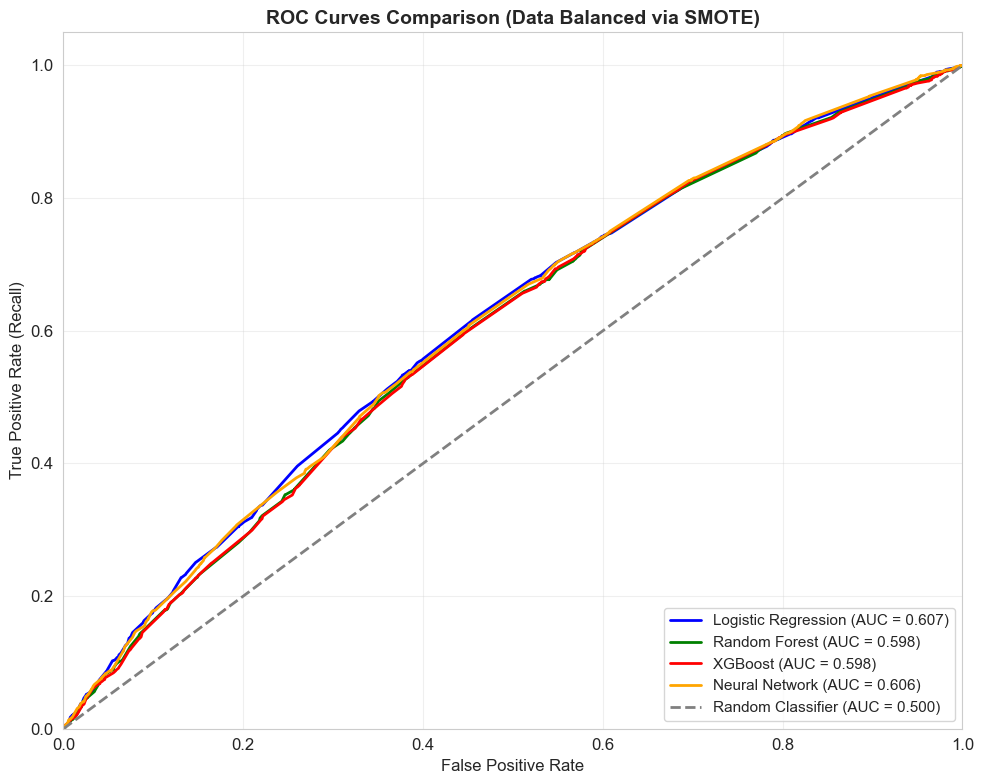

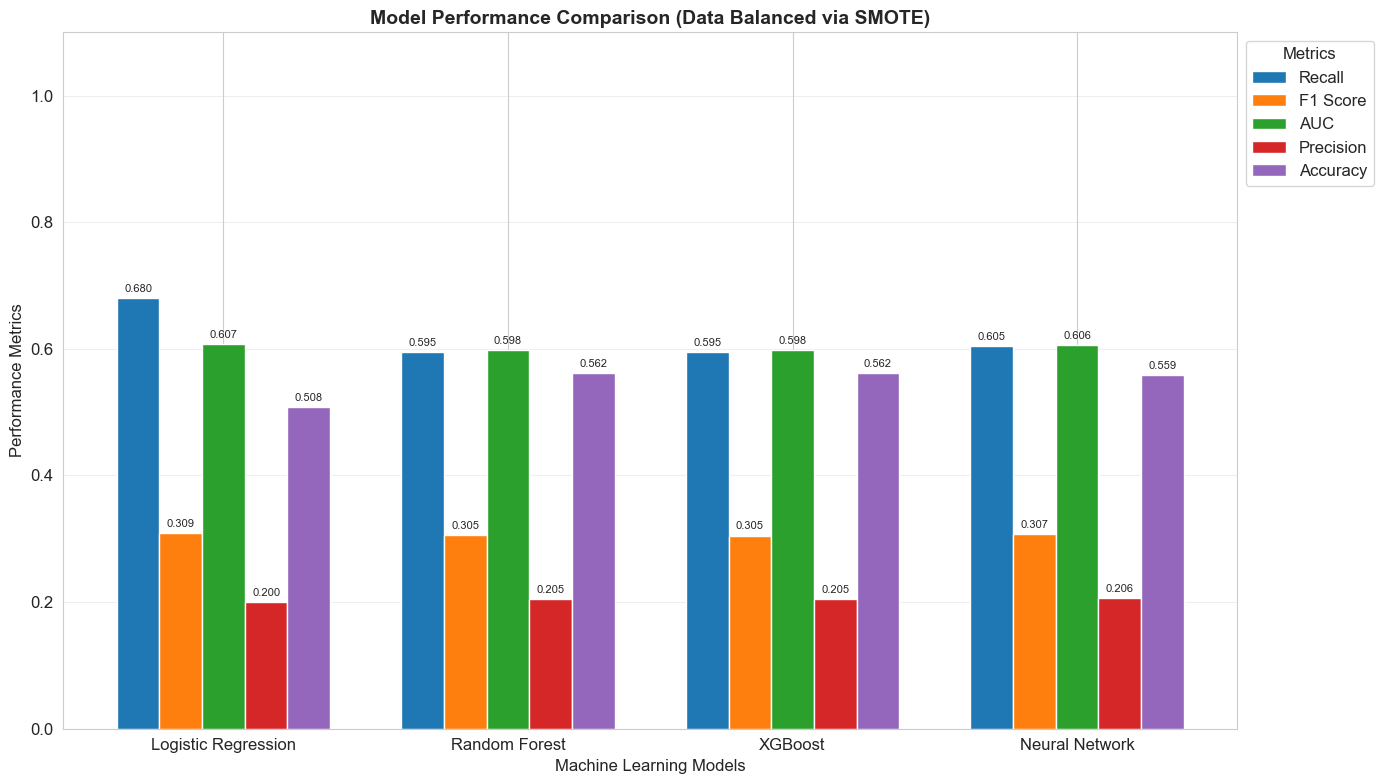

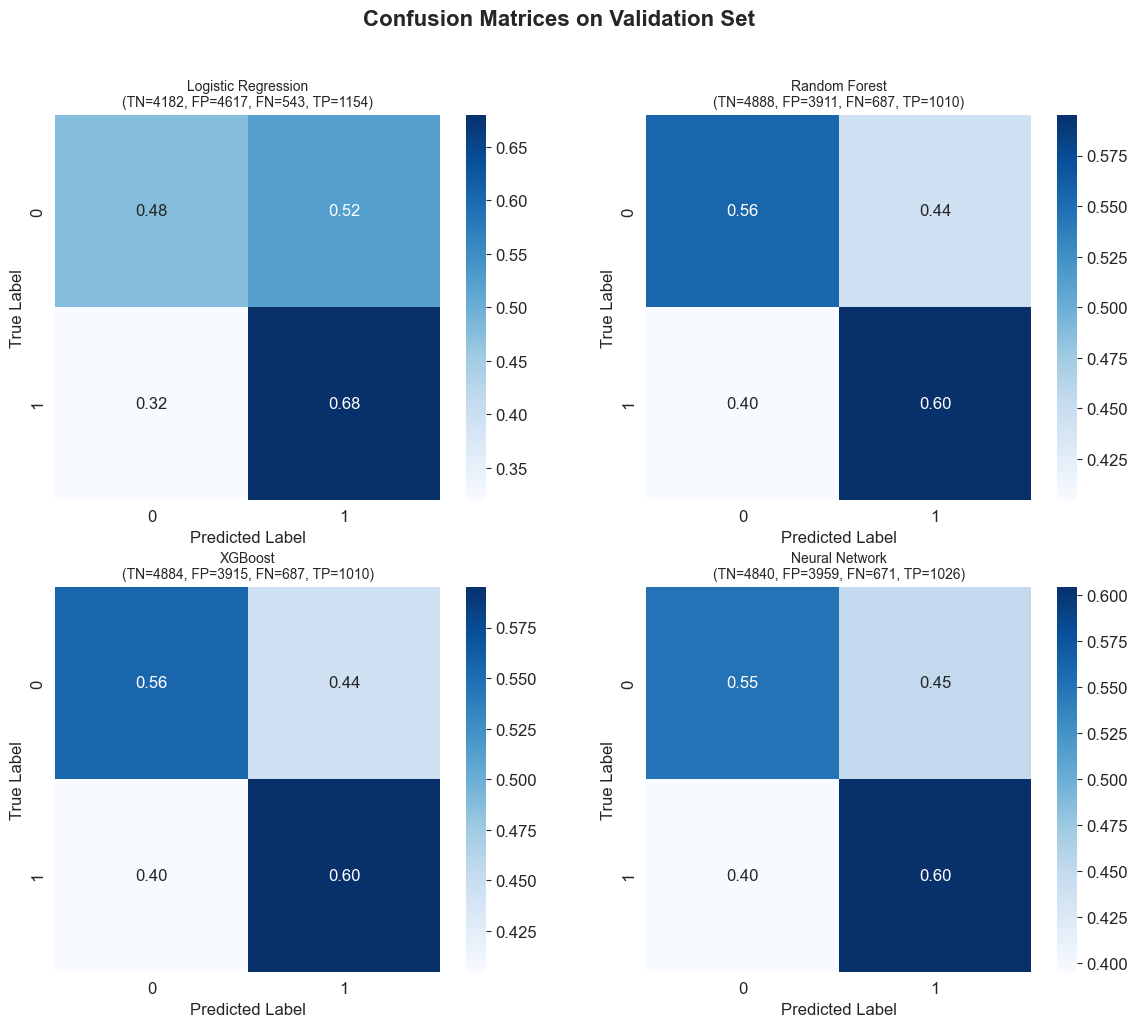

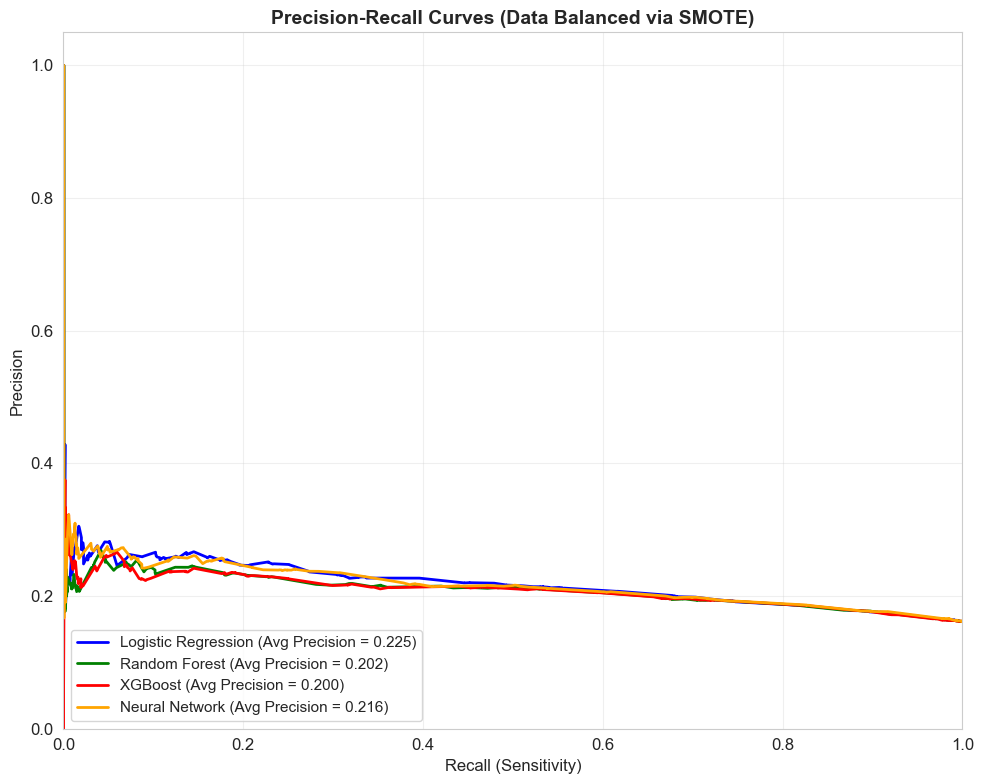


Feature Importance/Coefficient Analysis

Logistic Regression - Top 10 most important feature coefficients:
Feature              Coefficient Direction 
---------------------------------------------
age_squared          -0.9324    Negative  
age                  0.6352     Positive  
age_bp               0.1195     Positive  
pregnancy            -0.0930    Negative  
age_obesity          -0.0685    Negative  
alcohol              -0.0493    Negative  
race_Caucasian       -0.0478    Negative  
obesity              0.0460     Positive  
blood_pressure       -0.0365    Negative  
cholesterol          0.0365     Positive  

Random Forest - Top 10 most important features:
Feature              Importance Percentage
---------------------------------------------
age                  0.4178     41.8      %
age_group_encoded    0.1588     15.9      %
race_encoded         0.1284     12.8      %
risk_score           0.0917     9.2       %
gender               0.0429     4.3       %
pregnancy     

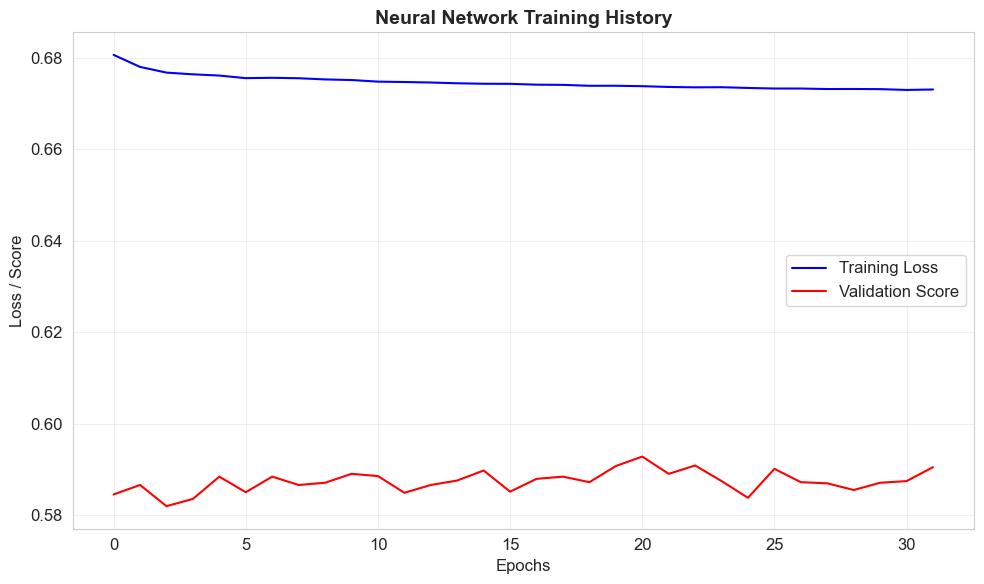


Best Hyperparameters Summary (Data Balanced via SMOTE)

Logistic Regression:
  C: 0.1
  penalty: l1

Random Forest:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: None

XGBoost:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 200
  subsample: 0.8

Neural Network:
  activation: relu
  alpha: 0.01
  hidden_layer_sizes: (100, 50)
  learning_rate_init: 0.001

Step 3: Selecting best model for healthcare...

Model Selection for Healthcare Applications (Data Balanced via SMOTE)

1. Sorted by RECALL (Most important in healthcare):
  1. Logistic Regression: recall=0.6800
  2. Neural Network: recall=0.6046
  3. Random Forest: recall=0.5952
  4. XGBoost: recall=0.5952

2. Sorted by F1:
  1. Logistic Regression: f1=0.3091
  2. Neural Network: f1=0.3071
  3. Random Forest: f1=0.3052
  4. XGBoost: f1=0.3050

3. Comprehensive Evaluation Table (Healthcare Weighted):
-------------------------------------------------------

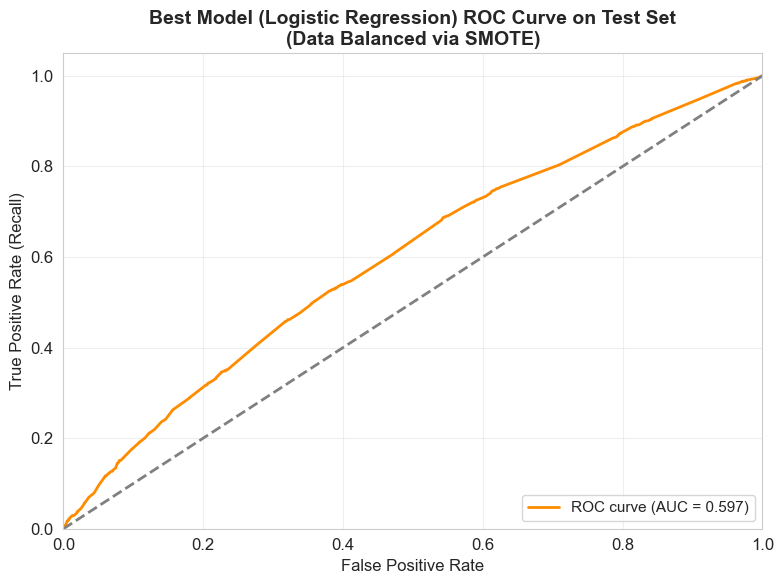


Workflow Complete!
Best Model: Logistic Regression
Test Recall: 0.6859
Test F1 Score: 0.3048
Test AUC: 0.5965
Test Precision: 0.1959
Test Accuracy: 0.4941


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import xgboost as xgb

def train_all_models_with_visualization(model_datasets):
    """
    Train four models (including Neural Network) and perform visual comparison
    Note: Class imbalance has been handled at data level (SMOTE)
    """
    models = {}
    val_results = {}
    
    print("="*60)
    print("Multi-Model Training (Class Imbalance Handled via SMOTE)")
    print("="*60)
    
    # ==================== 1. Logistic Regression ====================
    print("\n1. Training Logistic Regression model...")
    lr_data = model_datasets['logistic_regression']
    X_train_lr, y_train_lr = lr_data['train']
    X_val_lr, y_val_lr = lr_data['val']
    
    # Note: No class_weight since data is already balanced via SMOTE
    lr_model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='liblinear'
    )
    
    # Logistic regression hyperparameter tuning
    lr_param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    }
    
    lr_grid = GridSearchCV(
        lr_model, 
        lr_param_grid, 
        cv=5, 
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    lr_grid.fit(X_train_lr, y_train_lr)
    lr_best = lr_grid.best_estimator_
    models['Logistic Regression'] = lr_best
    
    # Evaluate on validation set
    y_val_pred_lr = lr_best.predict(X_val_lr)
    y_val_prob_lr = lr_best.predict_proba(X_val_lr)[:, 1]
    
    val_results['Logistic Regression'] = {
        'accuracy': accuracy_score(y_val_lr, y_val_pred_lr),
        'precision': precision_score(y_val_lr, y_val_pred_lr, zero_division=0),
        'recall': recall_score(y_val_lr, y_val_pred_lr, zero_division=0),
        'f1': f1_score(y_val_lr, y_val_pred_lr, zero_division=0),
        'auc': roc_auc_score(y_val_lr, y_val_prob_lr),
        'model': lr_best,
        'predictions': y_val_pred_lr,
        'probabilities': y_val_prob_lr,
        'best_params': lr_grid.best_params_
    }
    
    # ==================== 2. Random Forest ====================
    print("\n2. Training Random Forest model...")
    rf_data = model_datasets['random_forest']
    X_train_rf, y_train_rf = rf_data['train']
    X_val_rf, y_val_rf = rf_data['val']
    
    # Note: No class_weight since data is already balanced via SMOTE
    rf_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )
    
    # Random forest hyperparameter tuning
    rf_param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    rf_random = RandomizedSearchCV(
        rf_model,
        rf_param_dist,
        n_iter=15,
        cv=3,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    rf_random.fit(X_train_rf, y_train_rf)
    rf_best = rf_random.best_estimator_
    models['Random Forest'] = rf_best
    
    # Evaluate on validation set
    y_val_pred_rf = rf_best.predict(X_val_rf)
    y_val_prob_rf = rf_best.predict_proba(X_val_rf)[:, 1]
    
    val_results['Random Forest'] = {
        'accuracy': accuracy_score(y_val_rf, y_val_pred_rf),
        'precision': precision_score(y_val_rf, y_val_pred_rf, zero_division=0),
        'recall': recall_score(y_val_rf, y_val_pred_rf, zero_division=0),
        'f1': f1_score(y_val_rf, y_val_pred_rf, zero_division=0),
        'auc': roc_auc_score(y_val_rf, y_val_prob_rf),
        'model': rf_best,
        'predictions': y_val_pred_rf,
        'probabilities': y_val_prob_rf,
        'best_params': rf_random.best_params_
    }
    
    # ==================== 3. XGBoost ====================
    print("\n3. Training XGBoost model...")
    xgb_data = model_datasets['xgboost']
    X_train_xgb, y_train_xgb = xgb_data['train']
    X_val_xgb, y_val_xgb = xgb_data['val']
    
    # Convert data type to XGBoost required format
    if hasattr(X_train_xgb, 'values'):
        X_train_xgb_array = X_train_xgb.values
        X_val_xgb_array = X_val_xgb.values
    else:
        X_train_xgb_array = X_train_xgb
        X_val_xgb_array = X_val_xgb
    
    # Note: No scale_pos_weight since data is already balanced via SMOTE
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    )
    
    # XGBoost hyperparameter tuning
    xgb_param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
    
    xgb_grid = GridSearchCV(
        xgb_model,
        xgb_param_grid,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    xgb_grid.fit(X_train_xgb_array, y_train_xgb)
    xgb_best = xgb_grid.best_estimator_
    models['XGBoost'] = xgb_best
    
    # Evaluate on validation set
    y_val_pred_xgb = xgb_best.predict(X_val_xgb_array)
    y_val_prob_xgb = xgb_best.predict_proba(X_val_xgb_array)[:, 1]
    
    val_results['XGBoost'] = {
        'accuracy': accuracy_score(y_val_xgb, y_val_pred_xgb),
        'precision': precision_score(y_val_xgb, y_val_pred_xgb, zero_division=0),
        'recall': recall_score(y_val_xgb, y_val_pred_xgb, zero_division=0),
        'f1': f1_score(y_val_xgb, y_val_pred_xgb, zero_division=0),
        'auc': roc_auc_score(y_val_xgb, y_val_prob_xgb),
        'model': xgb_best,
        'predictions': y_val_pred_xgb,
        'probabilities': y_val_prob_xgb,
        'best_params': xgb_grid.best_params_
    }
    
    # ==================== 4. Neural Network ====================
    print("\n4. Training Neural Network model...")
    nn_data = model_datasets['neural_network']
    X_train_nn, y_train_nn = nn_data['train']
    X_val_nn, y_val_nn = nn_data['val']
    
    # Note: No class_weight needed since data is already balanced via SMOTE
    
    
    nn_model = MLPClassifier(
        random_state=42,
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=10,
        verbose=0
    )
    
    # Neural network hyperparameter tuning
    nn_param_grid = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01, 0.1]
    }
    
    nn_grid = GridSearchCV(
        nn_model,
        nn_param_grid,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    nn_grid.fit(X_train_nn, y_train_nn)
    nn_best = nn_grid.best_estimator_
    models['Neural Network'] = nn_best
    
    # Evaluate on validation set
    y_val_pred_nn = nn_best.predict(X_val_nn)
    y_val_prob_nn = nn_best.predict_proba(X_val_nn)[:, 1]
    
    val_results['Neural Network'] = {
        'accuracy': accuracy_score(y_val_nn, y_val_pred_nn),
        'precision': precision_score(y_val_nn, y_val_pred_nn, zero_division=0),
        'recall': recall_score(y_val_nn, y_val_pred_nn, zero_division=0),
        'f1': f1_score(y_val_nn, y_val_pred_nn, zero_division=0),
        'auc': roc_auc_score(y_val_nn, y_val_prob_nn),
        'model': nn_best,
        'predictions': y_val_pred_nn,
        'probabilities': y_val_prob_nn,
        'best_params': nn_grid.best_params_
    }
    
    # ==================== Print all model performances ====================
    print("\n" + "="*60)
    print("All Model Performance on Validation Set")
    print("="*60)
    
    # Sort models by recall (most important for healthcare)
    sorted_results = sorted(val_results.items(), key=lambda x: x[1]['recall'], reverse=True)
    
    for name, metrics in sorted_results:
        print(f"\n{name}:")
        print(f"  Recall (Sensitivity): {metrics['recall']:.4f} (Most critical medical indicators)")
        print(f"  F1 Score: {metrics['f1']:.4f}")
        print(f"  AUC-ROC: {metrics['auc']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
    
    # ==================== Visualization Section ====================
    
    # Prepare validation data for each model
    val_data = {}
    for name, metrics in val_results.items():
        if name == 'Logistic Regression':
            X_val_data = X_val_lr
            y_val_data = y_val_lr
        elif name == 'Random Forest':
            X_val_data = X_val_rf
            y_val_data = y_val_rf
        elif name == 'XGBoost':
            X_val_data = X_val_xgb_array if 'X_val_xgb_array' in locals() else X_val_xgb
            y_val_data = y_val_xgb
        elif name == 'Neural Network':
            X_val_data = X_val_nn
            y_val_data = y_val_nn
        
        val_data[name] = {
            'X_val': X_val_data,
            'y_val': y_val_data,
            'model': metrics['model']
        }
    
    # 1. ROC Curve Comparison
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'green', 'red', 'orange'][:len(models)]  
    
    for idx, (name, data) in enumerate(val_data.items()):
        model = data['model']
        y_val = data['y_val']
        
        # Get prediction probabilities
        if name == 'XGBoost' and hasattr(data['X_val'], 'values'):
            X_val_array = data['X_val'].values
        else:
            X_val_array = data['X_val']
        
        y_val_prob = model.predict_proba(X_val_array)[:, 1]
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_val, y_val_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, color=colors[idx], lw=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
             label='Random Classifier (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curves Comparison (Data Balanced via SMOTE)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 2. Model Performance Bar Chart (Focus on recall and F1)
    metrics_names = ['Recall', 'F1 Score', 'AUC', 'Precision', 'Accuracy']
    model_names = list(models.keys())
    
    metric_values = {
        'Recall': [val_results[name]['recall'] for name in model_names],
        'F1 Score': [val_results[name]['f1'] for name in model_names],
        'AUC': [val_results[name]['auc'] for name in model_names],
        'Precision': [val_results[name]['precision'] for name in model_names],
        'Accuracy': [val_results[name]['accuracy'] for name in model_names]
    }
    
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(model_names))
    width = 0.15
    
    for i, (metric, values) in enumerate(metric_values.items()):
        offset = width * (i - len(metrics_names)/2 + 0.5)
        bars = ax.bar(x + offset, values, width, label=metric)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Machine Learning Models', fontsize=12)
    ax.set_ylabel('Performance Metrics', fontsize=12)
    ax.set_title('Model Performance Comparison (Data Balanced via SMOTE)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylim([0, 1.1])
    ax.legend(title='Metrics', loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Confusion Matrices with improved visualization
        # 3. Confusion Matrices
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Confusion Matrices on Validation Set', fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(val_data.items()):
        if idx >= len(axes):
            break
            
        model = data['model']
        y_val = data['y_val']
        
        # Get prediction results
        if name == 'XGBoost' and hasattr(data['X_val'], 'values'):
            X_val_array = data['X_val'].values
        else:
            X_val_array = data['X_val']
        
        y_val_pred = model.predict(X_val_array)
        cm = confusion_matrix(y_val, y_val_pred)
        
        # Normalize confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Plot heatmap
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                    cbar=True, square=True, ax=axes[idx])
        axes[idx].set_title(f'{name}\n(TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]})', fontsize=10)
        axes[idx].set_xlabel('Predicted Label')
        axes[idx].set_ylabel('True Label')
    
    # Hide extra subplots
    for idx in range(len(val_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Precision-Recall Curves
    plt.figure(figsize=(10, 8))
    
    for idx, (name, data) in enumerate(val_data.items()):
        model = data['model']
        y_val = data['y_val']
        
        if name == 'XGBoost' and hasattr(data['X_val'], 'values'):
            X_val_array = data['X_val'].values
        else:
            X_val_array = data['X_val']
        
        y_val_prob = model.predict_proba(X_val_array)[:, 1]
        precision, recall, _ = precision_recall_curve(y_val, y_val_prob)
        avg_precision = np.mean(precision)
        
        plt.plot(recall, precision, color=colors[idx], lw=2,
                 label=f'{name} (Avg Precision = {avg_precision:.3f})')
    
    plt.xlabel('Recall (Sensitivity)', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves (Data Balanced via SMOTE)', fontsize=14, fontweight='bold')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.legend(loc='lower left', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 5. Feature Importance/Coefficient Analysis
    print("\n" + "="*60)
    print("Feature Importance/Coefficient Analysis")
    print("="*60)
    
    # 5.1 Logistic regression coefficients
    print("\nLogistic Regression - Top 10 most important feature coefficients:")
    lr_model = models['Logistic Regression']
    
    if hasattr(X_train_lr, 'columns'):
        feature_names = X_train_lr.columns.tolist()
    else:
        feature_names = [f'Feature_{i}' for i in range(X_train_lr.shape[1])]
    
    lr_coefficients = lr_model.coef_[0]
    lr_importance = np.abs(lr_coefficients)
    lr_indices = np.argsort(lr_importance)[::-1][:10]
    
    print(f"{'Feature':<20} {'Coefficient':<10} {'Direction':<10}")
    print("-" * 45)
    for idx in lr_indices:
        feature_name = feature_names[idx] if idx < len(feature_names) else f'Feature_{idx}'
        direction = "Positive" if lr_coefficients[idx] > 0 else "Negative"
        print(f"{feature_name:<20} {lr_coefficients[idx]:<10.4f} {direction:<10}")
    
    # 5.2 Tree model feature importance
    tree_models = {
        'Random Forest': models['Random Forest'],
        'XGBoost': models['XGBoost']
    }
    
    for name, model in tree_models.items():
        print(f"\n{name} - Top 10 most important features:")
        
        # Get feature names
        if name == 'Random Forest':
            if hasattr(X_train_rf, 'columns'):
                feature_names = X_train_rf.columns.tolist()
            else:
                feature_names = [f'Feature_{i}' for i in range(X_train_rf.shape[1])]
        elif name == 'XGBoost':
            if hasattr(X_train_xgb, 'columns'):
                feature_names = X_train_xgb.columns.tolist()
            else:
                feature_names = [f'Feature_{i}' for i in range(X_train_xgb.shape[1])]
        
        # Get feature importance
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:10]
            
            print(f"{'Feature':<20} {'Importance':<10} {'Percentage':<10}")
            print("-" * 45)
            total_importance = np.sum(importances)
            for idx in indices:
                feature_name = feature_names[idx] if idx < len(feature_names) else f'Feature_{idx}'
                percentage = (importances[idx] / total_importance) * 100
                print(f"{feature_name:<20} {importances[idx]:<10.4f} {percentage:<10.1f}%")
    
    # 5.3 Neural Network training history visualization
    print("\nNeural Network - Training History:")
    if hasattr(nn_best, 'loss_curve_'):
        plt.figure(figsize=(10, 6))
        plt.plot(nn_best.loss_curve_, label='Training Loss', color='blue')
        if hasattr(nn_best, 'validation_scores_'):
            plt.plot(nn_best.validation_scores_, label='Validation Score', color='red')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss / Score', fontsize=12)
        plt.title('Neural Network Training History', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # 6. Best Parameters Summary
    print("\n" + "="*60)
    print("Best Hyperparameters Summary (Data Balanced via SMOTE)")
    print("="*60)
    
    for name, metrics in val_results.items():
        print(f"\n{name}:")
        if 'best_params' in metrics:
            for param, value in metrics['best_params'].items():
                print(f"  {param}: {value}")
    
    return models, val_results, val_data


def select_best_model_for_healthcare(val_results, 
                                    primary_metric='recall',
                                    secondary_metric='f1'):
    """
    Select the best model based on healthcare application requirements
    Healthcare scenario priority: recall > F1 > AUC > precision > accuracy
    """
    print("\n" + "="*60)
    print("Model Selection for Healthcare Applications (Data Balanced via SMOTE)")
    print("="*60)
    
    # 1. Sort by primary metric
    print(f"\n1. Sorted by {primary_metric.upper()} (Most important in healthcare):")
    models_by_primary = sorted(val_results.items(), 
                              key=lambda x: x[1][primary_metric], 
                              reverse=True)
    
    for i, (name, metrics) in enumerate(models_by_primary, 1):
        print(f"  {i}. {name}: {primary_metric}={metrics[primary_metric]:.4f}")
    
    # 2. Sort by secondary metric
    print(f"\n2. Sorted by {secondary_metric.upper()}:")
    models_by_secondary = sorted(val_results.items(), 
                                key=lambda x: x[1][secondary_metric], 
                                reverse=True)
    
    for i, (name, metrics) in enumerate(models_by_secondary, 1):
        print(f"  {i}. {name}: {secondary_metric}={metrics[secondary_metric]:.4f}")
    
    # 3. Comprehensive evaluation table
    print("\n3. Comprehensive Evaluation Table (Healthcare Weighted):")
    print("-" * 90)
    print(f"{'Model':<20} {'Recall':<10} {'F1':<10} {'AUC':<10} {'Precision':<10} {'Accuracy':<10} {'Weighted Score*':<10}")
    print("-" * 90)
    
    for name, metrics in val_results.items():
        # Calculate weighted score (healthcare scenario weights)
        weighted_score = (
            metrics['recall'] * 0.40 +      # 40% weight to recall (most important)
            metrics['f1'] * 0.30 +          # 30% weight to F1 (balanced metric)
            metrics['auc'] * 0.20 +         # 20% weight to AUC
            metrics['precision'] * 0.05 +   # 5% weight to precision
            metrics['accuracy'] * 0.05      # 5% weight to accuracy
        )
        
        print(f"{name:<20} {metrics['recall']:<10.4f} {metrics['f1']:<10.4f} "
              f"{metrics['auc']:<10.4f} {metrics['precision']:<10.4f} "
              f"{metrics['accuracy']:<10.4f} {weighted_score:<10.4f}")
    
    print("-" * 90)
    print("*Weighted Score: Recall(40%) + F1(30%) + AUC(20%) + Precision(5%) + Accuracy(5%)")
    
    # 4. Select best model with different criteria
    best_by_weighted = max(val_results.items(), 
                          key=lambda x: (
                              x[1]['recall'] * 0.40 +
                              x[1]['f1'] * 0.30 +
                              x[1]['auc'] * 0.20 +
                              x[1]['precision'] * 0.05 +
                              x[1]['accuracy'] * 0.05
                          ))
    
    best_by_recall = max(val_results.items(), 
                        key=lambda x: x[1]['recall'])
    
    best_by_f1 = max(val_results.items(), 
                    key=lambda x: x[1]['f1'])
    
    # Display best models under different criteria
    print("\n4. Best Models Under Different Criteria:")
    print("-" * 60)
    print(f"By Recall (Clinical priority):   {best_by_recall[0]} - Recall={best_by_recall[1]['recall']:.4f}")
    print(f"By F1 Score (Balanced metric):   {best_by_f1[0]} - F1={best_by_f1[1]['f1']:.4f}")
    print(f"By Weighted Score:               {best_by_weighted[0]} - Score={best_by_weighted[1]['recall']*0.45 + best_by_weighted[1]['f1']*0.25 + best_by_weighted[1]['auc']*0.20:.4f}")
    
    # Recommended best model (based on healthcare application requirements)
    print("\n5. Recommended Model for Healthcare Applications:")
    print("-" * 60)
    
    recall_diff = abs(best_by_recall[1]['recall'] - best_by_f1[1]['recall'])
    f1_diff = abs(best_by_recall[1]['f1'] - best_by_f1[1]['f1'])
    
    # Decision logic: If the recall rates are not significantly different, choose the one with a higher F1. If the recall rates vary significantly, choose the one with a higher recall rate
    if recall_diff < 0.05 and f1_diff > 0.05:
        recommended_model = best_by_f1
        reason = "Recall values are similar (<0.05 difference), choosing model with higher F1 score for balanced performance"
    else:
        recommended_model = best_by_recall
        reason = "Higher recall is crucial in healthcare applications to reduce false negatives (missed diagnoses)"
    
    print(f"Recommended Model: {recommended_model[0]}")
    print(f"Reason: {reason}")
    print(f"\nKey Metrics of Recommended Model:")
    print(f"  • Recall (Sensitivity): {recommended_model[1]['recall']:.4f}")
    print(f"  • F1 Score: {recommended_model[1]['f1']:.4f}")
    print(f"  • AUC-ROC: {recommended_model[1]['auc']:.4f}")
    print(f"  • Precision: {recommended_model[1]['precision']:.4f}")
    print(f"  • Accuracy: {recommended_model[1]['accuracy']:.4f}")
    
    return recommended_model[0], recommended_model[1]['model']


# ==================== Complete Workflow Example ====================

def complete_training_workflow(df_original, apply_smote=True, sampling_method='smote'):
    """
    Complete workflow for training models with SMOTE preprocessing
    """
    print("="*60)
    print("Complete Training Workflow with SMOTE Preprocessing")
    print("="*60)
    
    # 1. Prepare datasets with SMOTE
    print("\nStep 1: Preparing datasets with SMOTE...")
    model_datasets = prepare_all_model_datasets(
        df_original=df_original,
        apply_smote=apply_smote,
        sampling_method=sampling_method,
        random_state=42
    )
    
    # 2. Train all models and perform visualization
    print("\nStep 2: Training all models...")
    models, val_results, val_data = train_all_models_with_visualization(model_datasets)
    
    # 3. Select best model
    print("\nStep 3: Selecting best model for healthcare...")
    best_model_name, best_model = select_best_model_for_healthcare(val_results)
    
    print(f"\nFinal Selected Best Model: {best_model_name}")
    
    # 4. Evaluate best model on test set
    print("\n" + "="*60)
    print("Evaluating Best Model on Test Set")
    print("="*60)
    
    # Get corresponding test data based on selected model
    if best_model_name == 'Logistic Regression':
        X_test = model_datasets['logistic_regression']['test'][0]
        y_test = model_datasets['logistic_regression']['test'][1]
    elif best_model_name == 'Random Forest':
        X_test = model_datasets['random_forest']['test'][0]
        y_test = model_datasets['random_forest']['test'][1]
    elif best_model_name == 'XGBoost':
        X_test = model_datasets['xgboost']['test'][0]
        y_test = model_datasets['xgboost']['test'][1]
    elif best_model_name == 'Neural Network':
        X_test = model_datasets['neural_network']['test'][0]
        y_test = model_datasets['neural_network']['test'][1]
    
    # Convert data type (if needed)
    if best_model_name == 'XGBoost' and hasattr(X_test, 'values'):
        X_test_array = X_test.values
    else:
        X_test_array = X_test
    
    # Make predictions on test set
    y_test_pred = best_model.predict(X_test_array)
    y_test_prob = best_model.predict_proba(X_test_array)[:, 1]
    
    # Calculate test set metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    print(f"\nBest Model ({best_model_name}) Performance on Test Set:")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  F1 Score: {test_f1:.4f}")
    print(f"  AUC-ROC: {test_auc:.4f}")
    
    # Plot ROC curve for test set
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
    roc_auc_test = auc(fpr_test, tpr_test)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc_test:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title(f'Best Model ({best_model_name}) ROC Curve on Test Set\n(Data Balanced via SMOTE)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 5. Additional visualization: Feature importance for tree-based models
    if best_model_name in ['Random Forest', 'XGBoost']:
        print("\n" + "="*60)
        print(f"Feature Importance Analysis for {best_model_name}")
        print("="*60)
        
        if hasattr(best_model, 'feature_importances_'):
            # Get feature names
            if best_model_name == 'Random Forest':
                if hasattr(model_datasets['random_forest']['train'][0], 'columns'):
                    feature_names = model_datasets['random_forest']['train'][0].columns.tolist()
                else:
                    feature_names = [f'Feature_{i}' for i in range(model_datasets['random_forest']['train'][0].shape[1])]
            else:  # XGBoost
                if hasattr(model_datasets['xgboost']['train'][0], 'columns'):
                    feature_names = model_datasets['xgboost']['train'][0].columns.tolist()
                else:
                    feature_names = [f'Feature_{i}' for i in range(model_datasets['xgboost']['train'][0].shape[1])]
            
            # Get feature importances
            importances = best_model.feature_importances_
            indices = np.argsort(importances)[::-1][:15]
            
            # Plot feature importance
            plt.figure(figsize=(12, 8))
            plt.title(f'Feature Importances - {best_model_name}', fontsize=16, fontweight='bold')
            plt.bar(range(len(indices)), importances[indices], align='center')
            plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
            plt.xlabel('Features', fontsize=12)
            plt.ylabel('Importance', fontsize=12)
            plt.tight_layout()
            plt.show()
            
            # Print top features
            print(f"\nTop 15 Most Important Features in {best_model_name}:")
            print("-" * 60)
            print(f"{'Feature':<25} {'Importance':<10} {'Percentage':<10}")
            print("-" * 60)
            total_importance = np.sum(importances)
            for idx in indices:
                feature_name = feature_names[idx] if idx < len(feature_names) else f'Feature_{idx}'
                percentage = (importances[idx] / total_importance) * 100
                print(f"{feature_name:<25} {importances[idx]:<10.4f} {percentage:<10.1f}%")
    
    return {
        'best_model_name': best_model_name,
        'best_model': best_model,
        'models': models,
        'val_results': val_results,
        'test_metrics': {
            'accuracy': test_accuracy,
            'precision': test_precision,
            'recall': test_recall,
            'f1': test_f1,
            'auc': test_auc
        },
        'model_datasets': model_datasets
    }


# ==================== Usage Example ====================

if __name__ == "__main__":
    # Example usage (assuming you have df2 as your original data)
    # df2 = pd.read_csv('your_data.csv')
    
    # Run complete workflow with SMOTE
    results = complete_training_workflow(
        df_original=df2,
        apply_smote=True,
        sampling_method='smote'
    )
    
    print("\n" + "="*60)
    print("Workflow Complete!")
    print("="*60)
    print(f"Best Model: {results['best_model_name']}")
    print(f"Test Recall: {results['test_metrics']['recall']:.4f}")
    print(f"Test F1 Score: {results['test_metrics']['f1']:.4f}")
    print(f"Test AUC: {results['test_metrics']['auc']:.4f}")
    print(f"Test Precision: {results['test_metrics']['precision']:.4f}")
    print(f"Test Accuracy: {results['test_metrics']['accuracy']:.4f}")